# ANALYSIS

  In this notebook, we investigate whether parking lot occupancy at Walmart stores can serve as a reliable proxy for the company's nominal in-store sales. This
  approach is grounded in the broader practice of alternative data in financial analysis, where non-traditional signals, such as satellite imagery, credit card
  transactions, or web scraping, are used to nowcast economic and corporate performance ahead of official disclosures.

  Parking lot occupancy is a particularly well-established alternative data signal: institutional investors and hedge funds have long used aerial and satellite
  imagery of retail parking lots to estimate foot traffic and anticipate quarterly earnings releases before they are publicly reported. The underlying assumption is
  that vehicle counts in parking lots are a leading indicator of consumer activity at a given retailer.

  In our case, we use NAIP (National Agriculture Imagery Program) aerial imagery to estimate occupancy rates across a sample of Walmart locations from 2012 to 2022,
  and test whether the yearly average occupancy correlates with Walmart's nominal in-store sales over the same period. Rather than building a predictive model, our
  goal is to validate the proxy relationship itself, establishing whether this visual signal carries meaningful information about retail performance

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df_pib = pd.read_csv("../../Data/walmart_instore_deflator.csv")
df_occupancy = pd.read_csv("../../Data/naip_occupancy_results.csv")

In [16]:
df_pib.head()


,year,Nominal_walmart_sales,inflation,Multiplier,Cumulative_Inflation_Index,Normalized_walmart_sales
0,2011,413052,1.640277,1.016403,1.438571,594205
1,2012,436490,3.156529,1.031565,1.394551,608708
2,2013,456433,2.069450,1.020694,1.366277,623614
3,2014,462007,1.464760,1.014648,1.346553,622117
4,2015,469280,1.622188,1.016222,1.325058,621824


In [17]:
df_occupancy.head()

,store_id,date,occupancy,year
0,42,2012-06-22,0.042379,2012
1,42,2015-08-20,0.048267,2015
2,42,2023-06-06,0.029109,2023
3,111,2012-06-25,0.027813,2012
4,111,2014-07-05,0.035563,2014


The Pearson correlation coefficient is: 0.8543


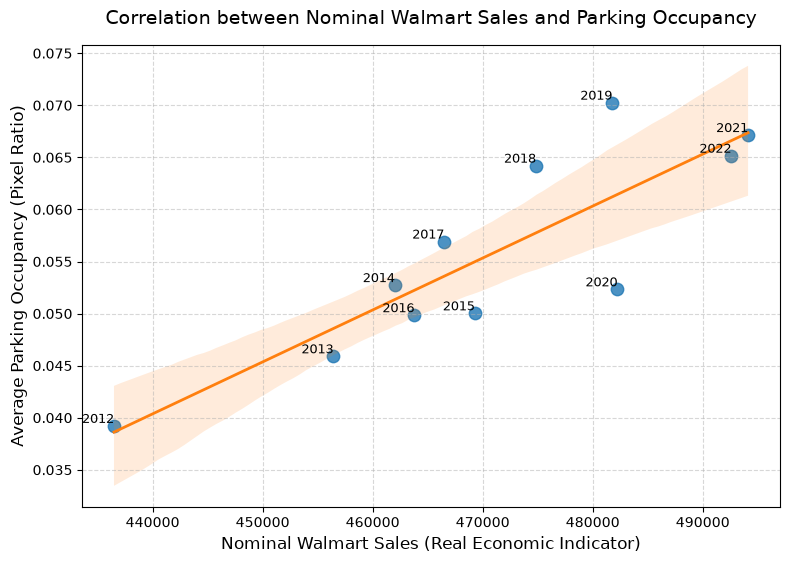

In [19]:
# Filter occupancy data to years up to 2022
df_occupancy_filtered = df_occupancy[(df_occupancy['year'] <= 2022) & (df_occupancy['year'] > 2011)]

# Group the occupancy data by year and calculate the mean occupancy for each year
df_occ_yearly = df_occupancy_filtered.groupby('year')['occupancy'].mean().reset_index()

# Merge the occupancy data with the normalized GDP data on the 'year' column
df_correlation = pd.merge(df_occ_yearly, df_pib[['year', 'Nominal_walmart_sales']], on='year')

# Compute the Pearson correlation coefficient between Nominal_walmart_sales and occupancy
correlation_matrix = df_correlation[['Nominal_walmart_sales', 'occupancy']].corr()
correlation_value = correlation_matrix.loc['Nominal_walmart_sales', 'occupancy']

print(f"The Pearson correlation coefficient is: {correlation_value:.4f}")

# Visualization
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df_correlation, 
    x='Nominal_walmart_sales', 
    y='occupancy', 
    scatter_kws={'s': 80, 'color': '#1f77b4', 'alpha': 0.8},
    line_kws={'color': '#ff7f0e', 'linewidth': 2}
)
for i in range(df_correlation.shape[0]):
    plt.text(
        df_correlation['Nominal_walmart_sales'].iloc[i], 
        df_correlation['occupancy'].iloc[i], 
        str(int(df_correlation['year'].iloc[i])),
        verticalalignment='bottom', 
        horizontalalignment='right',
        fontsize=9
    )

plt.title('Correlation between Nominal Walmart Sales and Parking Occupancy', fontsize=14, pad=15)
plt.xlabel('Nominal Walmart Sales (Real Economic Indicator)', fontsize=12)
plt.ylabel('Average Parking Occupancy (Pixel Ratio)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()